# Plot multiple `Name, X, Y` sample files

This notebook reads **all CSV files in a folder**. Each file can contain any number of repeated `Name, X, Y` blocks:

`Name, X, Y, Name, X, Y, ...`

Set `FOLDER_PATH` below to the folder containing the files.

In [1]:
# ==============================
# USER SETTINGS
# ==============================

FOLDER_PATH = r"H:\FUBerlin\PhD Update Presentations\AboutDWCNTs_KIT_Shivani\DATA"

# File extension to read
FILE_PATTERN = "*.csv"

# If True, make one figure for each file.
# If False, combine all files into one figure.
PLOT_EACH_FILE_SEPARATELY = True

# Set to True if you also want PNG files saved next to the input files.
SAVE_FIGURES = False

# Folder for saved figures. None = same folder as input files.
OUTPUT_FOLDER = None


In [2]:
import csv
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt


def read_samples(filename):
    """Read repeated Name,X,Y blocks from one CSV file."""
    samples = {}

    with open(filename, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)

        try:
            header = next(reader)
        except StopIteration:
            raise ValueError(f"Empty file: {filename}")

        if len(header) < 3 or len(header) % 3 != 0:
            raise ValueError(
                f"{filename}: number of columns ({len(header)}) "
                "must be a multiple of 3."
            )

        n_samples = len(header) // 3

        for row_number, row in enumerate(reader, start=2):
            if not row or all(not cell.strip() for cell in row):
                continue

            if len(row) < 3 * n_samples:
                row = row + [""] * (3 * n_samples - len(row))

            if len(row) > 3 * n_samples:
                raise ValueError(
                    f"{filename}, row {row_number}: found {len(row)} columns; "
                    f"expected {3 * n_samples}."
                )

            for i in range(n_samples):
                name = row[3*i].strip()
                x_text = row[3*i + 1].strip()
                y_text = row[3*i + 2].strip()

                if not name or not x_text or not y_text:
                    continue

                try:
                    x = float(x_text)
                    y = float(y_text)
                except ValueError:
                    print(
                        f"Warning: invalid X/Y in {filename}, "
                        f"row {row_number}, sample {i+1}"
                    )
                    continue

                samples.setdefault(name, ([], []))
                samples[name][0].append(x)
                samples[name][1].append(y)

    return samples


def read_folder(folder_path, pattern="*.csv"):
    """Read all matching files in a folder."""
    folder = Path(folder_path)
    files = sorted(folder.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"No files matching {pattern!r} found in {folder}"
        )

    data = {}
    for file in files:
        try:
            data[file] = read_samples(file)
        except Exception as e:
            print(f"Skipping {file.name}: {e}")

    return data


In [3]:
# Read all files
all_data = read_folder(FOLDER_PATH, FILE_PATTERN)

print(f"Found {len(all_data)} readable files.\n")

for file, samples in all_data.items():
    print(f"{file.name}: {len(samples)} samples")
    for name, (x, y) in samples.items():
        print(f"    {name}: {len(x)} points")


Found 12 readable files.

RamanFilmSamples_GDBand_514nm.csv: 6 samples
    Film T1 S-SWCNTs: 966 points
    Film T1 S-SWCNTs Converted: 966 points
    Film T2 S-SWCNTs: 966 points
    Film T2 S-SWCNTs Converted: 966 points
    Film T9 M-SWCNTs: 966 points
    Film T9 M-SWCNTs Converted: 966 points
RamanFilmSamples_GDBand_561nm.csv: 6 samples
    Film T1S (SWCNT): 1820 points
    Film T1S (Converted to DWCNT): 1820 points
    Film T2S (SWCNT): 1820 points
    Film T2S (Converted to DWCNT): 1820 points
    Film T9M (SWCNT): 1820 points
    Film T9M (Converted to DWCNT): 1820 points
RamanFilmSamples_RBM_514nm.csv: 6 samples
    Film T1 S-SWCNTs: 985 points
    Film T1 S-SWCNTs Converted: 985 points
    Film T2 S-SWCNTs: 985 points
    Film T2 S-SWCNTs Converted: 985 points
    Film T9 M-SWCNTs: 985 points
    Film T9 M-SWCNTs Converted: 985 points
RamanMetallicFilmSamples_RBM_561nm.csv: 2 samples
    Film T9 M-SWCNTs: 1024 points
    Film T9 M-SWCNTs Converted: 1024 points
RamanSemicondFi

## Plot

By default, every file gets its own figure, with all samples from that file plotted together.

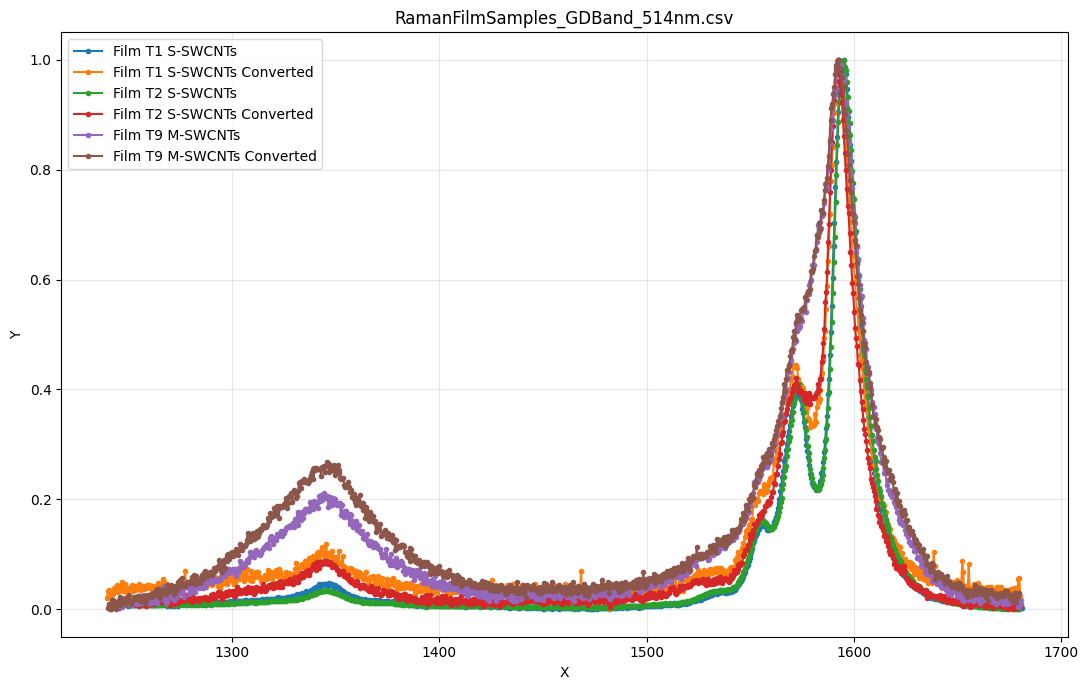

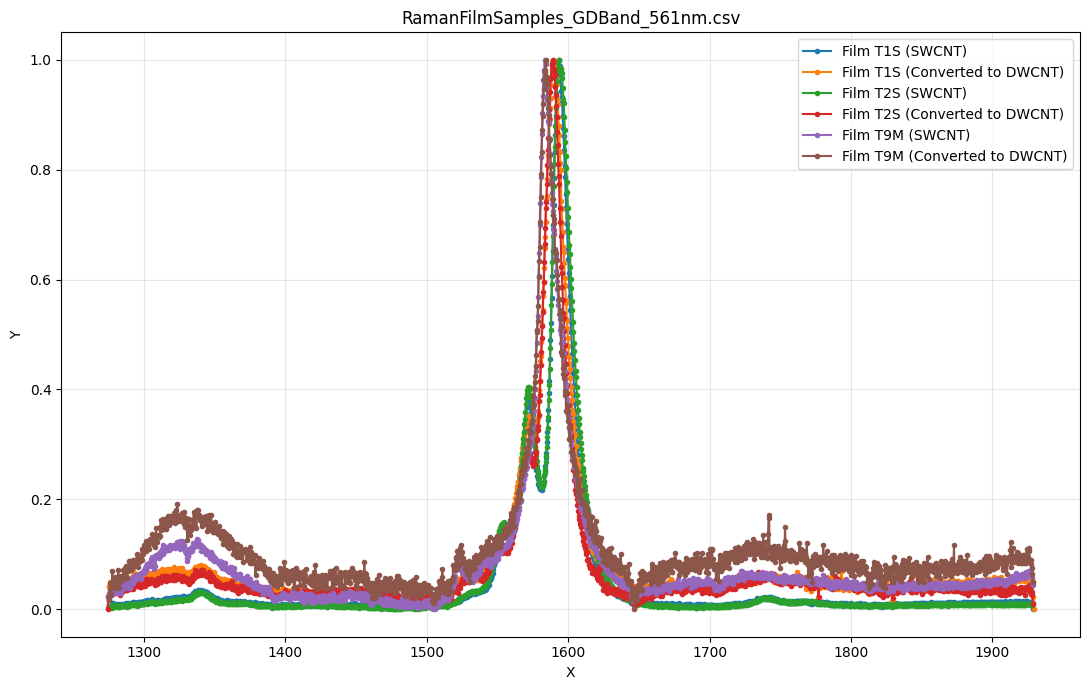

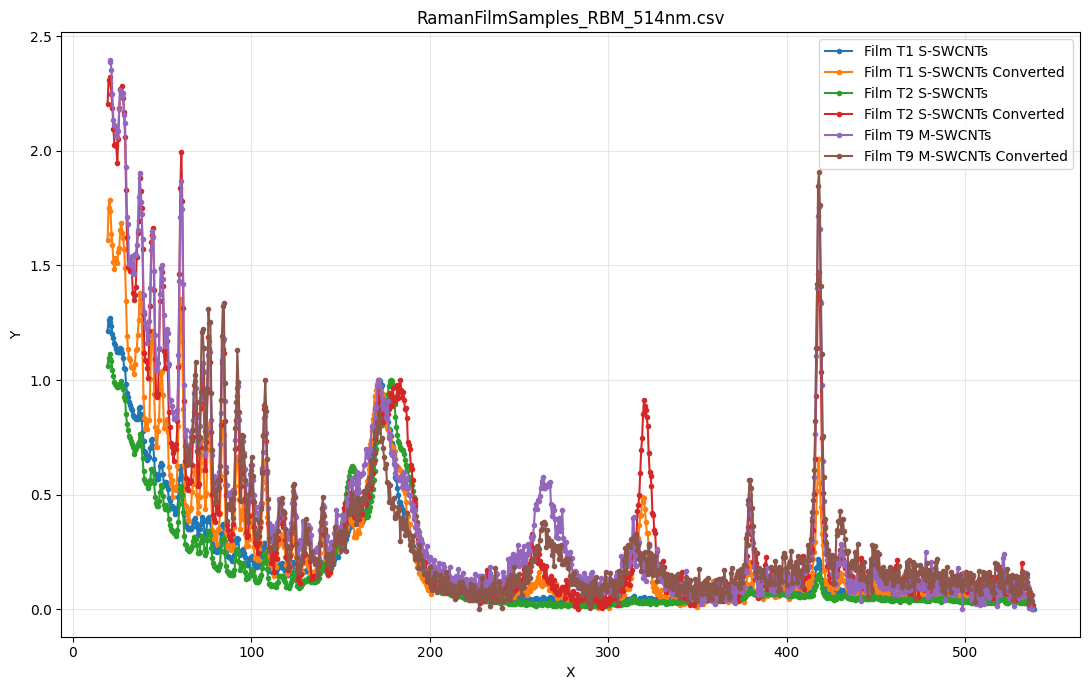

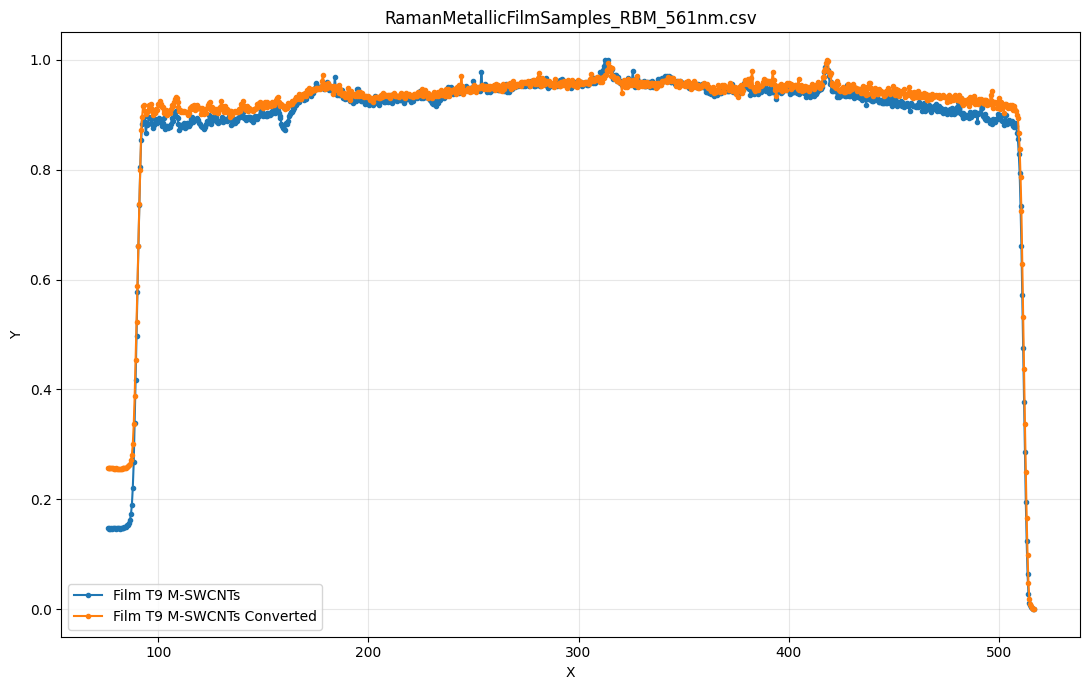

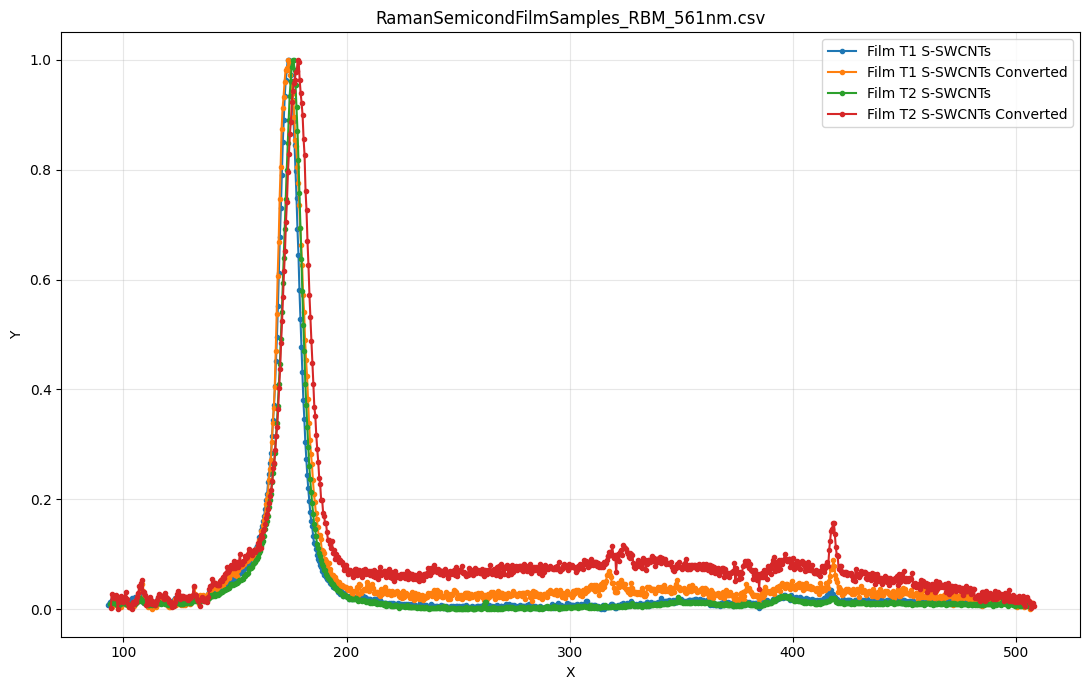

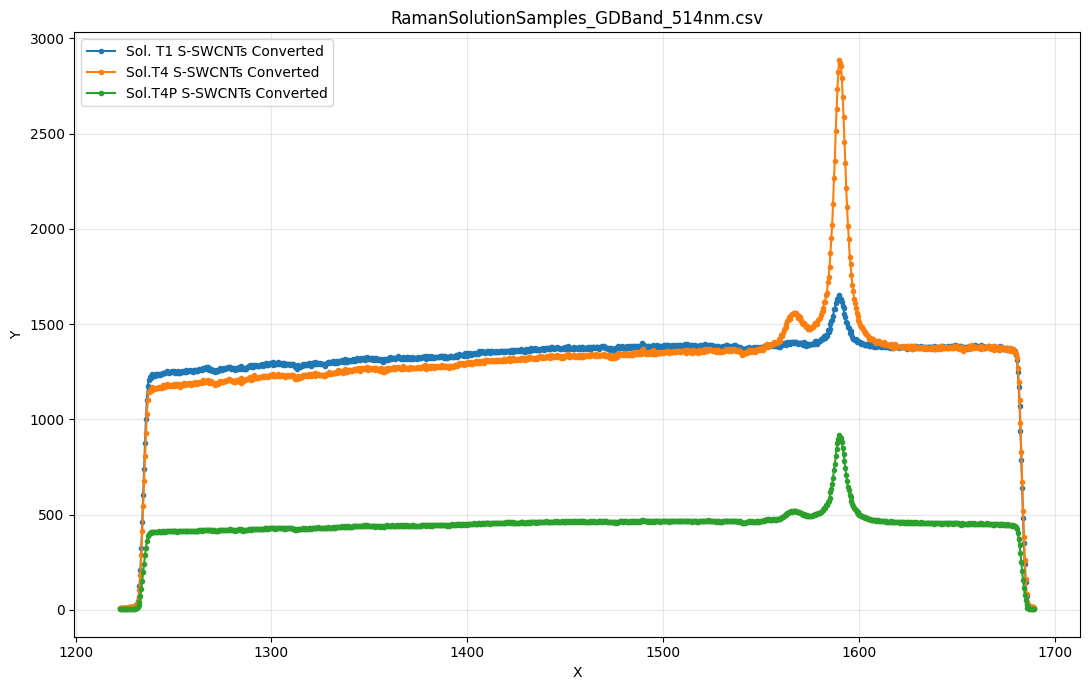

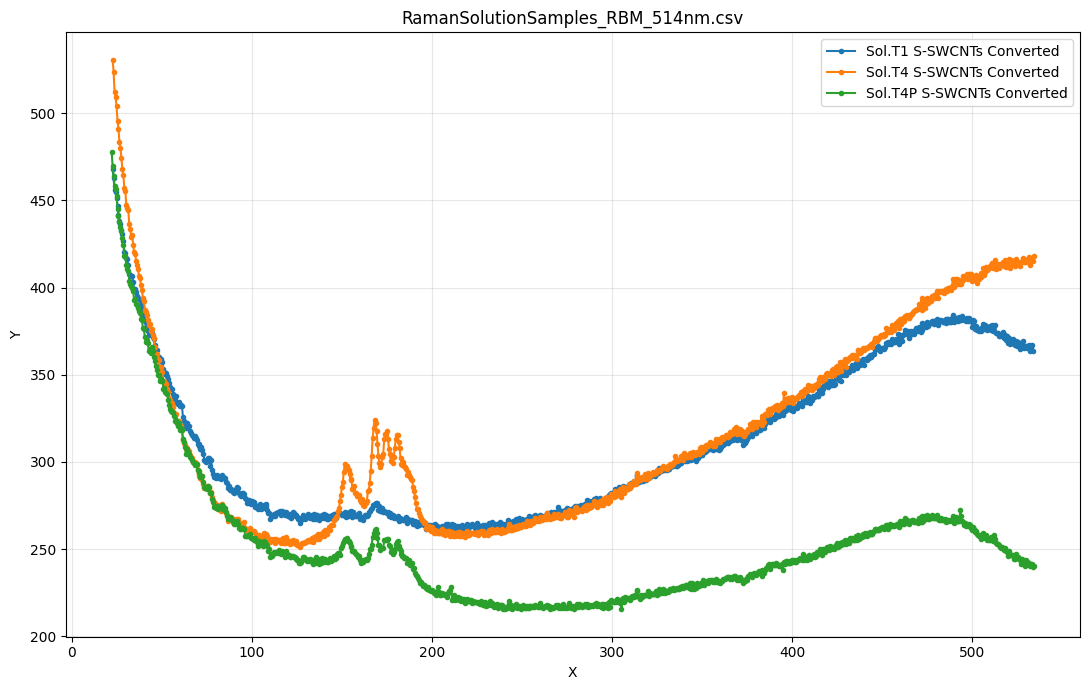

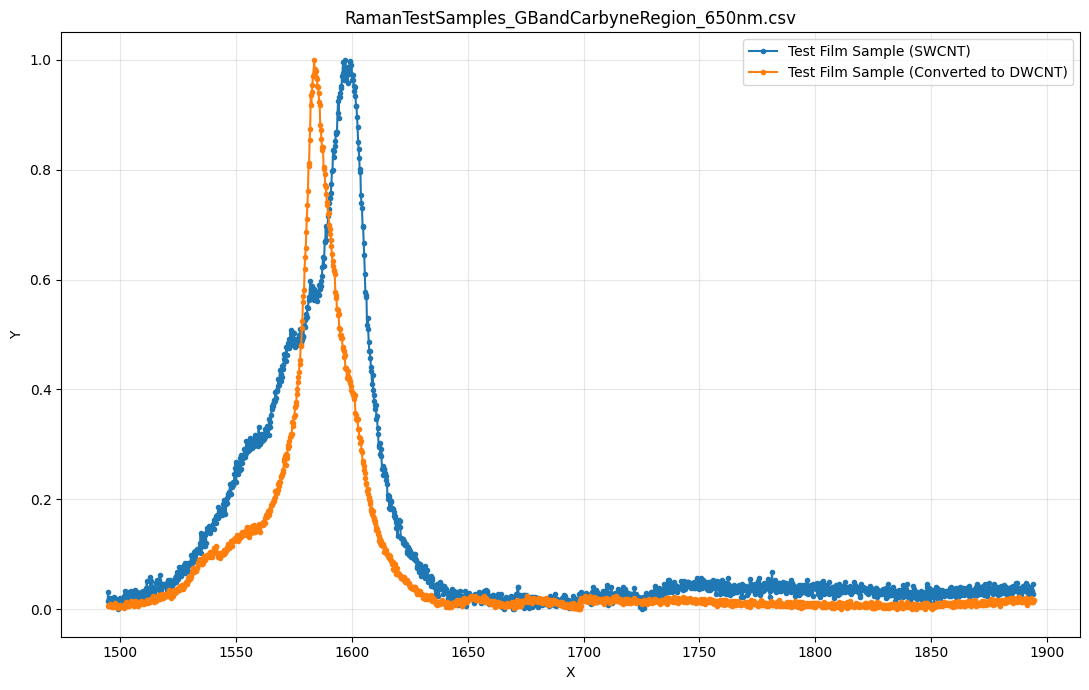

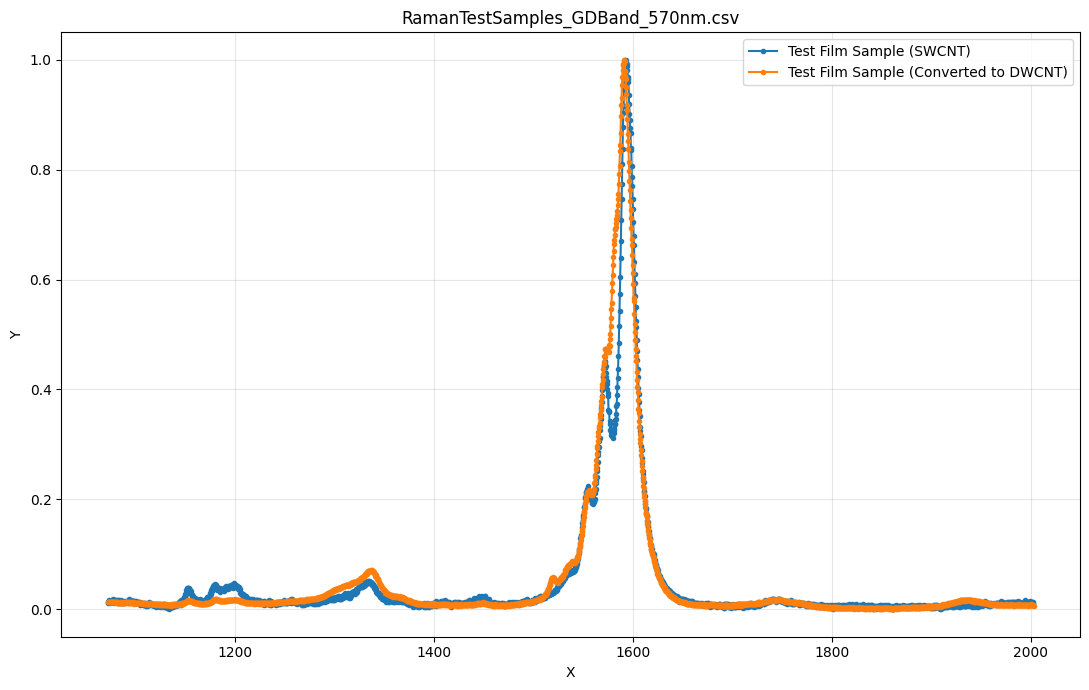

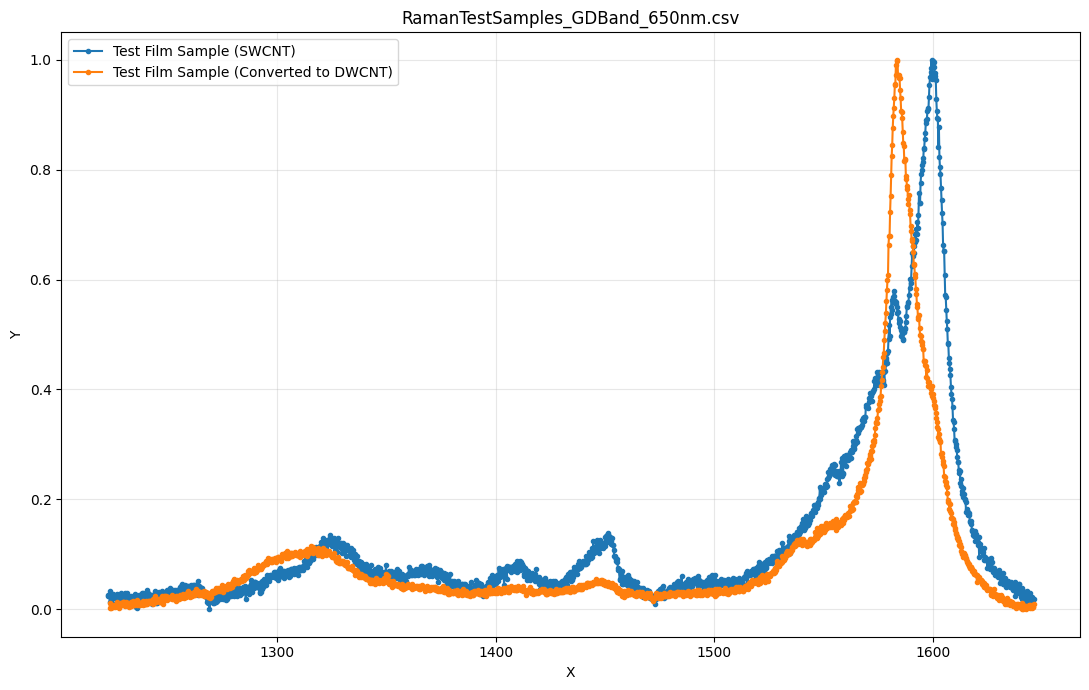

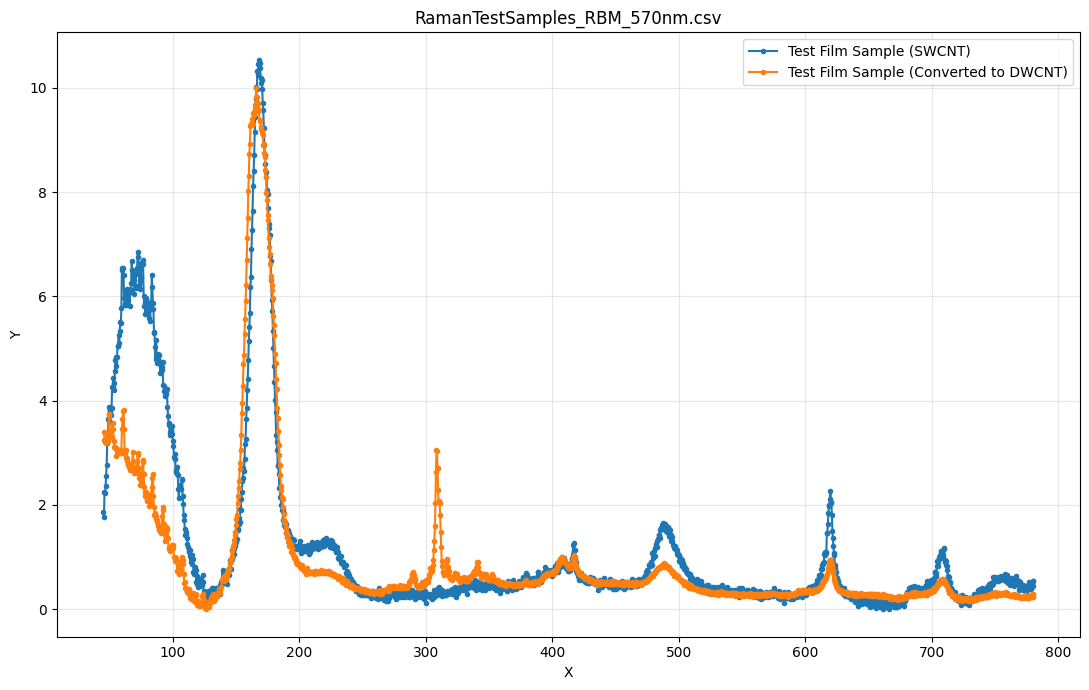

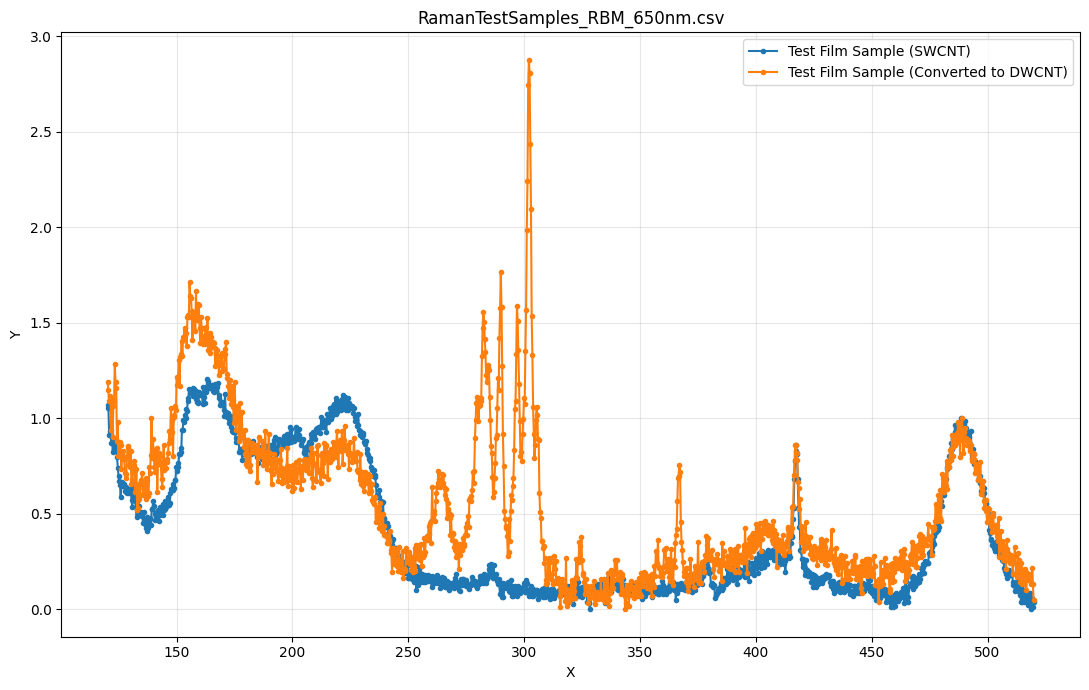

In [4]:
def plot_file(file, samples, save=False, output_folder=None):
    fig, ax = plt.subplots(figsize=(11, 7))

    for name, (x, y) in samples.items():
        ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(file.name)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if save:
        output_dir = Path(output_folder) if output_folder else file.parent
        output_dir.mkdir(parents=True, exist_ok=True)
        output_file = output_dir / f"{file.stem}.png"
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_file}")

    plt.show()
    plt.close(fig)


if PLOT_EACH_FILE_SEPARATELY:
    for file, samples in all_data.items():
        plot_file(
            file,
            samples,
            save=SAVE_FIGURES,
            output_folder=OUTPUT_FOLDER,
        )


## Optional: combine files

If you have several files representing measurements of the same samples, the following cell combines points from all files by sample name and plots them together.

In [5]:
if not PLOT_EACH_FILE_SEPARATELY:
    combined = defaultdict(lambda: ([], []))

    for file, samples in all_data.items():
        for name, (x, y) in samples.items():
            combined[name][0].extend(x)
            combined[name][1].extend(y)

    fig, ax = plt.subplots(figsize=(11, 7))

    for name, (x, y) in combined.items():
        ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("All files combined")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()
